In [1]:
## READS ON POSTPROCESS pqt, saves to disk
## Holy grail theory
## v1 - HA + JMA
# wish list:
# one more nudge/signal - whether HA candle body crosses JMA (need to write list of 
# handcrafted wick/body signals - try GBM first see if they add something statistically

In [2]:
import pandas as pd
import numpy as np
import datetime as dt 
from pathlib import Path
import time

In [3]:
# Configuration: Style preferences
#plt.style.use('ggplot') # Good default for readability
pd.set_option("display.width", 400)      # total characters per line
pd.set_option("display.max_columns", 30) # prevent wrapping by limiting columns
pd.set_option("display.max_rows", 1000)

In [4]:
%%time
file_name = 'ha-1sec-full'
IN_FILE   = f'/mnt/c/ml/data/2025/holy-grail/{file_name}.csv'
OUT_FILE  = f"{file_name}-train-v4.pqt"
RL_FILE   = f"{file_name}-rl-v4.pqt"

df = pd.read_csv(IN_FILE)

CPU times: user 1min 57s, sys: 24 s, total: 2min 21s
Wall time: 3min 57s


In [5]:
df.drop(columns=['G'], inplace=True)
df.rename(columns={'DateTime': 'timestamp'}, inplace=True)

## !!!!!!!!!!!!!!!! ##
# reducing it as adaptable Vel looks exactly the same as Vel(Jma)
df.drop(columns=['adpVelJma','adpVelJmaD1','adpVelJmaD2','adpVelJmaSign'], inplace=True) 

In [6]:
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 27643586 entries, 0 to 27643585
Data columns (total 48 columns):
 #   Column          Dtype  
---  ------          -----  
 0   timestamp       str    
 1   Open            float64
 2   High            float64
 3   Low             float64
 4   Close           float64
 5   haBody          float64
 6   haWickTop       float64
 7   haWickBott      float64
 8   haColour        int64  
 9   segmentId       int64  
 10  segmentLength   int64  
 11  g               int64  
 12  jma             float64
 13  jmaD1           float64
 14  jmaD2           float64
 15  jmaSign         int64  
 16  cfb             float64
 17  cfbD1           float64
 18  cfbD2           float64
 19  cfbSign         int64  
 20  rsxJma          float64
 21  rsxJmaD1        float64
 22  rsxJmaD2        float64
 23  rsxJmaSign      int64  
 24  rsxLast         float64
 25  rsxLastD1       float64
 26  rsxLastD2       float64
 27  rsxLastSign     int64  
 28  momRsxJma       float

In [7]:
# Note - decided against it = the LGBM and everything down the line uses this df, not sure if source df items wont downgrade LGBM internal values
#float_cols = df.select_dtypes(include="float64").columns.difference(sign_cols)
#df[float_cols] = df[float_cols].astype("float32")

sign_cols = df.columns[df.columns.str.endswith("Sign")]
df[sign_cols] = df[sign_cols].astype("int8")

# schema
type_spec = {
    'haColour': 'int8',
    'segmentId': 'uint16',
    'segmentLength': 'uint8',
    'g': 'int8',
}

# Apply conversion
df = df.astype(type_spec)

# cast to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 27643586 entries, 0 to 27643585
Data columns (total 48 columns):
 #   Column          Dtype         
---  ------          -----         
 0   timestamp       datetime64[us]
 1   Open            float64       
 2   High            float64       
 3   Low             float64       
 4   Close           float64       
 5   haBody          float64       
 6   haWickTop       float64       
 7   haWickBott      float64       
 8   haColour        int8          
 9   segmentId       uint16        
 10  segmentLength   uint8         
 11  g               int8          
 12  jma             float64       
 13  jmaD1           float64       
 14  jmaD2           float64       
 15  jmaSign         int8          
 16  cfb             float64       
 17  cfbD1           float64       
 18  cfbD2           float64       
 19  cfbSign         int8          
 20  rsxJma          float64       
 21  rsxJmaD1        float64       
 22  rsxJmaD2        float64    

In [8]:
%%time

if not df["timestamp"].is_monotonic_increasing:
    raise ValueError("Unexpected unordered timestamp rows found")

df['date'] = df['timestamp'].dt.normalize()

day = pd.Timestamp("2025-11-28")
df = df[df["date"] != day]

CPU times: user 3.57 s, sys: 536 ms, total: 4.11 s
Wall time: 4.12 s


In [9]:
print(df["segmentLength"].max())
print('nan:', df.isna().any().any())

111
nan: False


In [10]:
%%time

"""
S2 input builder. Reads raw C# feature parquet, adds engineered ratio/trajectory
features, writes two model-input versions: 'signed' (direction intact) and
'symmetric' (direction folded out via slopeSign). Run both through the GBM probe
to test whether sign carries the edge.

Output is the versioned artifact you commit to git alongside the model version.
"""

#RAW = "features_raw.parquet"          # <-- raw C# output
EPS = 1e-9

# ---- integrity (the checks we already validated) ----
df["remaining"] = df["segmentLength"] - df["g"]
assert df["segmentLength"].min() == 1, "zero-length segment present"
assert df["remaining"].min() == 0, "g overruns segmentLength"
assert not df.isna().any().any(), "NaNs are not expected"

# HA Open above Jma = 1, below = -1
df["candleCross"] = np.sign(df["Open"] - df["jma"]).astype("int8")

# ---- engineered features ----
df["wickTop_body"] = df["haWickTop"] / (df["haBody"] + EPS)
df["wickBot_body"] = df["haWickBott"] / (df["haBody"] + EPS)
df["wickAsym"]     = (df["haWickBott"] - df["haWickTop"]) / (df["haBody"] + EPS)
df["wickSum_body"] = (df["haWickTop"] + df["haWickBott"]) / (df["haBody"] + EPS)
df["bodyRange"]    = df["haBody"] / (df["haBody"] + df["haWickTop"] + df["haWickBott"] + EPS)

# ---- short causal trajectory deltas (within-day; NaN at each day's first k rows) ----
date = df['date']
gd = df.groupby(date, sort=False)
df["dBody_3"]     = gd["haBody"].diff(3).fillna(0.0).values
df["dWickTopR_3"] = gd["wickTop_body"].diff(3).fillna(0.0).values
df["dWickBotR_3"] = gd["wickBot_body"].diff(3).fillna(0.0).values

CPU times: user 1.26 s, sys: 273 ms, total: 1.53 s
Wall time: 1.53 s


In [11]:
# for LGBM / Transformer - predict "remaining" (aka signed)
# trim columns
lgbm = df.drop(columns=[
    'Open',
    'High',
    'Low',
    'Close',
    'jma',
    'segmentLength',
])

# write
lgbm.to_parquet(OUT_FILE, index=False)
print(f"wrote {OUT_FILE} rows={len(df):,} days={date.nunique()}\n")

wrote ha-1sec-full-train-v4.pqt rows=27,627,765 days=1158



In [12]:
print(lgbm.info())
print(lgbm.head())
print(lgbm.tail())
print('\n== Note - start and end times are not exactly aligned as unfinished segments left out ==')

<class 'pandas.DataFrame'>
Index: 27627765 entries, 0 to 27643585
Data columns (total 53 columns):
 #   Column          Dtype         
---  ------          -----         
 0   timestamp       datetime64[us]
 1   haBody          float64       
 2   haWickTop       float64       
 3   haWickBott      float64       
 4   haColour        int8          
 5   segmentId       uint16        
 6   g               int8          
 7   jmaD1           float64       
 8   jmaD2           float64       
 9   jmaSign         int8          
 10  cfb             float64       
 11  cfbD1           float64       
 12  cfbD2           float64       
 13  cfbSign         int8          
 14  rsxJma          float64       
 15  rsxJmaD1        float64       
 16  rsxJmaD2        float64       
 17  rsxJmaSign      int8          
 18  rsxLast         float64       
 19  rsxLastD1       float64       
 20  rsxLastD2       float64       
 21  rsxLastSign     int8          
 22  momRsxJma       float64       
 

In [13]:
#  for LGBM / Transformer - predict "remaining"
# trim columns
keep = [
    'timestamp',
    'Open',
    'High',
    'Low',
    'Close',
    'jma',

    'jmaD1',
    'haColour',
    'jmaD2',
    'rsxLast',
    'rsxLastD1',
    'rsxLastD2',
    'cfbD1',
    'haBody',
    'candleCross',
    'wickAsym',
    'haWickTop',
    'haWickBott',
    'bodyRange',
    'dBody_3',
    'dWickTopR_3',
    'dWickBotR_3',
]

rl = df[keep]

# write
rl.to_parquet(RL_FILE, index=False)
print(f"wrote {RL_FILE} rows={len(df):,} days={date.nunique()}\n")

wrote ha-1sec-full-rl-v4.pqt rows=27,627,765 days=1158



In [14]:
print(rl.info())
print(rl.head())
print(rl.tail())
print('\n== Note - start and end times are not exactly aligned as unfinished segments left out ==')

<class 'pandas.DataFrame'>
Index: 27627765 entries, 0 to 27643585
Data columns (total 22 columns):
 #   Column       Dtype         
---  ------       -----         
 0   timestamp    datetime64[us]
 1   Open         float64       
 2   High         float64       
 3   Low          float64       
 4   Close        float64       
 5   jma          float64       
 6   jmaD1        float64       
 7   haColour     int8          
 8   jmaD2        float64       
 9   rsxLast      float64       
 10  rsxLastD1    float64       
 11  rsxLastD2    float64       
 12  cfbD1        float64       
 13  haBody       float64       
 14  candleCross  int8          
 15  wickAsym     float64       
 16  haWickTop    float64       
 17  haWickBott   float64       
 18  bodyRange    float64       
 19  dBody_3      float64       
 20  dWickTopR_3  float64       
 21  dWickBotR_3  float64       
dtypes: datetime64[us](1), float64(19), int8(2)
memory usage: 4.4 GB
None
            timestamp          Open

In [15]:
print(
    df['segmentLength']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
    .to_string(float_format=lambda x: f"{x:.1f}")
)

count   27627765.0
mean          15.2
std            9.8
min            1.0
25%            8.0
50%           13.0
75%           20.0
90%           28.0
95%           34.0
max          111.0


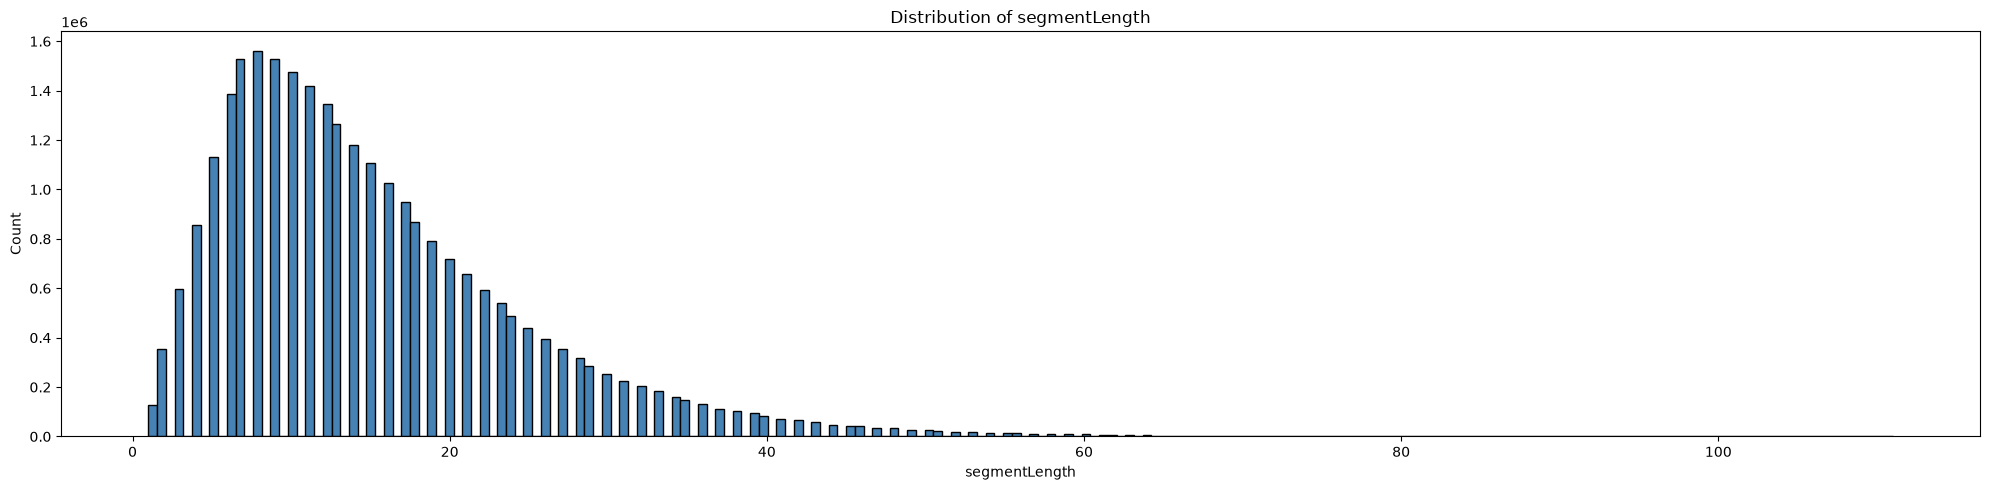

ZeroDivisionError: division by zero

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 5))
plt.hist(df['segmentLength'], bins=200, color='steelblue', edgecolor='black')
plt.xlabel("segmentLength")
plt.ylabel("Count")
plt.title("Distribution of segmentLength")
plt.tight_layout()
plt.show()

x = 1/0 ## the rest is useless - score removed, fields renamed


In [ ]:
# segmentId resets to 0 each day (per-call), so it is NOT unique across the concat.
# Build a real per-segment id from value-changes:
df['seg_uid'] = (df['segmentId'] != df['segmentId'].shift()).cumsum()

seg = df.groupby('seg_uid')['segmentLength'].first()
print(seg.describe(percentiles=[.5, .75, .9, .95, .99]))
print('frac <=3 :', (seg <= 3).mean())
print('frac ==1 :', (seg == 1).mean())

# label-machinery sanity (must hold while factor==1):
slen = df['segmentLength'].astype('float64')
#print('score_g==g :', (df['score_g'] == df['g']).all())
#print('score==tri :', np.allclose(df['score'], slen * (slen + 1) / 2))
print('nan        :', df.isna().any().any())

In [ ]:
z = df[df['segmentLength'] == 0]
print(len(z), z['seg_uid'].nunique())
print(z.groupby('seg_uid').size().describe())     # how big are the zero-len groups
print((z['timestamp'].dt.date.value_counts()).head())  # concentrated in certain days?

In [ ]:
#df['remaining'] = df['segmentLength'] - df['g']
print('min remain :', df['remaining'].min())   # MUST be 0; <0 = g exceeds its segment length (C# bug)
print('rows       :', len(df))
print('days       :', df['timestamp'].dt.date.nunique())

In [ ]:
x = 1/0

In [3]:
df = pd.read_parquet('./ha-3sec-full-rl-v4.pqt')

print("before timestamp:", df["timestamp"].dtype)

# optional safety check: only safe if ns part is already microsecond-aligned
ts_ns = df["timestamp"].to_numpy(dtype="datetime64[ns]").astype("int64")
bad = ts_ns % 1000 != 0

print("sub-microsecond rows:", bad.sum())

if bad.any():
    print("first bad row:", bad.argmax())
    print(df.loc[bad.argmax(), "timestamp"])
    raise RuntimeError("timestamp has real nanosecond precision; casting to us would truncate it")

df["timestamp"] = df["timestamp"].astype("datetime64[us]")
df["date"] = df["timestamp"].dt.normalize().astype("datetime64[us]")

print("after timestamp:", df["timestamp"].dtype)
print("after date:", df["date"].dtype)

before timestamp: datetime64[ns]
sub-microsecond rows: 0
after timestamp: datetime64[us]
after date: datetime64[us]


In [7]:
## adding lost `date` column as it is needed everywhere
filename = './ha-16sec-full-rl-v4.pqt'
df = pd.read_parquet(filename)

df["date"] = df["timestamp"].dt.normalize().astype("datetime64[us]")

df.to_parquet(filename, index=False)